In [ ]:
# 필요한 라이브러리 import
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt #한글 깨짐
from matplotlib import font_manager
f_path = 'C:\Windows\Fonts\malgun.ttf'
font_manager.FontProperties(fname=f_path).get_name()
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from itertools import combinations

<>:11: SyntaxWarning: invalid escape sequence '\W'
<>:11: SyntaxWarning: invalid escape sequence '\W'
C:\Users\nugikim\AppData\Local\Temp\ipykernel_14220\4047712973.py:11: SyntaxWarning: invalid escape sequence '\W'
  f_path = 'C:\Windows\Fonts\malgun.ttf'


In [28]:
# Step 1: 데이터 불러오기 및 전처리
# 데이터를 불러옵니다.
data = pd.read_excel('dataset.xlsx')
data

,id,sex,q1,q2,q3,q4,q5
0,1,남,0,2,0,70,통학
1,2,여,3,2,0,15,자취
2,3,남,0,0,0,300,통학
3,4,남,0,2,0,160,통학
4,5,남,1,2,0,200,통학
...,...,...,...,...,...,...,...
91,92,여성,2,3,0,90,통학
92,93,남성,7,0,2,60,통학
93,94,여성,3,3,0,90,통학
94,95,여성,1,1,3,15,자취


In [29]:
# 성별 데이터를 숫자로 변환합니다.
data['sex'] = data['sex'].replace({'남': 1, '남 ': 1, '남성': 1, '여': 2, '여성': 2}).astype(int)

C:\Users\nugikim\AppData\Local\Temp\ipykernel_14220\3131637930.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['sex'] = data['sex'].replace({'남': 1, '남 ': 1, '남성': 1, '여': 2, '여성': 2}).astype(int)


In [30]:
# 거주 형태 데이터를 숫자로 변환합니다.
data['q5'] = data['q5'].replace({'기숙사': 1, '자취': 2, '통학': 3})

C:\Users\nugikim\AppData\Local\Temp\ipykernel_14220\3309922582.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['q5'] = data['q5'].replace({'기숙사': 1, '자취': 2, '통학': 3})


In [31]:
# q5의 더미 변수를 생성하여 분석에 활용할 수 있도록 준비합니다.
q5_dummies = pd.get_dummies(data['q5'], prefix='q5', drop_first=True)
data = pd.concat([data, q5_dummies], axis=1)

In [32]:
# Step 2: 기본 통계 확인
print("성별에 따른 q1 값 통계 요약")
print(data.groupby('sex')['q1'].describe())

성별에 따른 q1 값 통계 요약
     count      mean       std  min  25%  50%  75%  max
sex                                                    
1     53.0  2.358491  1.932459  0.0  1.0  2.0  3.0  7.0
2     43.0  2.046512  1.731411  0.0  1.0  2.0  3.0  7.0


In [33]:
# Step 3: 단순 회귀 분석
# 성별(sex)이 q1과 q2의 관계에 미치는 영향을 확인합니다.
model = smf.ols('q1 ~ q2 * sex', data=data).fit()
print("\n단순 회귀 분석 결과")
print(model.summary())


단순 회귀 분석 결과
                            OLS Regression Results                            
Dep. Variable:                     q1   R-squared:                       0.164
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     6.027
Date:                Sun, 17 Nov 2024   Prob (F-statistic):           0.000856
Time:                        15:58:05   Log-Likelihood:                -185.76
No. Observations:                  96   AIC:                             379.5
Df Residuals:                      92   BIC:                             389.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.4370      0.987      1

In [34]:
# Step 4: 모든 변수 조합 회귀 분석
# 종속 변수와 독립 변수 설정
y = data['q1']
X = data[['q2', 'q3', 'q4', 'q5']]

In [35]:
# 가능한 모든 변수 조합 생성 함수
def get_all_combinations(features):
    combinations_list = []
    for r in range(1, len(features) + 1):
        combinations_list.extend(combinations(features, r))
    return combinations_list

feature_combinations = get_all_combinations(X.columns)

In [16]:
# 각 조합에 대해 회귀 분석 결과를 저장
results = []
for comb in feature_combinations:
    X_comb = sm.add_constant(data[list(comb)])
    model = sm.OLS(y, X_comb).fit()
    results.append({
        'Variables': comb,
        'R-squared': model.rsquared,
        'Adj. R-squared': model.rsquared_adj,
        'AIC': model.aic,
        'BIC': model.bic
    })

results_df = pd.DataFrame(results).sort_values(by='R-squared', ascending=False)
print("\n모든 변수 조합 회귀 결과")
print(results_df)


모든 변수 조합 회귀 결과
           Variables  R-squared  Adj. R-squared         AIC         BIC
14  (q2, q3, q4, q5)   0.278974        0.247281  367.337019  380.158760
11      (q2, q3, q5)   0.277571        0.254013  365.523747  375.781140
10      (q2, q3, q4)   0.267746        0.243868  366.820450  377.077843
4           (q2, q3)   0.260191        0.244281  365.805887  373.498932
12      (q2, q4, q5)   0.170908        0.143872  378.744041  389.001434
6           (q2, q5)   0.167596        0.149694  377.126813  384.819858
5           (q2, q4)   0.155590        0.137430  378.501563  386.194608
0              (q2,)   0.155513        0.146529  376.510229  381.638925
13      (q3, q4, q5)   0.149180        0.121436  381.227469  391.484862
8           (q3, q5)   0.148960        0.130658  379.252334  386.945379
7           (q3, q4)   0.140270        0.121781  380.227663  387.920707
1              (q3,)   0.136949        0.127768  378.597691  383.726387
9           (q4, q5)   0.015707       -0.005461 

In [17]:
# Step 5: 다중공선성 확인
X_vif = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("\n다중공선성 (VIF) 결과")
print(vif_data)


다중공선성 (VIF) 결과
  Variable        VIF
0    const  73.984807
1       q2   1.023751
2       q3   1.108370
3       q4   1.311074
4       q5   1.200427


In [18]:
# Step 6: 이상값과 영향력 있는 관찰값 확인
model = sm.OLS(y, sm.add_constant(X)).fit()
influence = model.get_influence()
leverage = influence.hat_matrix_diag
studentized_residuals = influence.resid_studentized_external

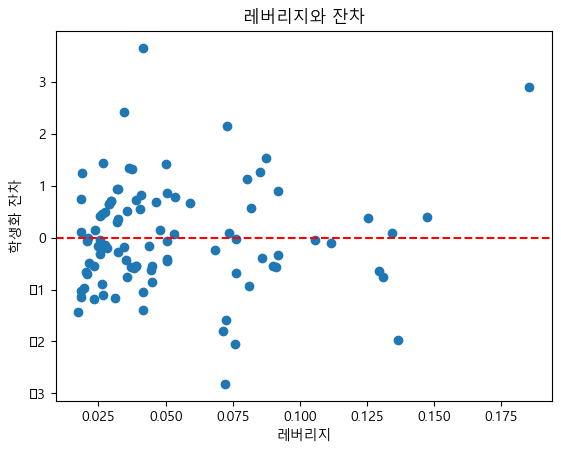

In [24]:
#한글 깨짐
from matplotlib import rc
rc('font', family='Malgun Gothic')

# 이상값 시각화
plt.scatter(leverage, studentized_residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('레버리지')
plt.ylabel('학생화 잔차')
plt.title('레버리지와 잔차')
plt.show()

In [25]:
# Step 7: 다항 회귀 분석
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(data[['q2', 'q3']])
X_poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(['q2', 'q3']))

model_poly = LinearRegression()
model_poly.fit(X_poly, y)

intercept = model_poly.intercept_
coefs = model_poly.coef_

print("\n다항 회귀 분석 회귀식")
terms = " + ".join([f"({coefs[i]})*{name}" for i, name in enumerate(X_poly_df.columns)])
print(f"y = {intercept} + {terms}")


다항 회귀 분석 회귀식
y = 0.6247114300121381 + (0.7242207726194317)*q2 + (0.47636932525977077)*q3 + (-0.06294868510484958)*q2^2 + (0.018507011183169664)*q2 q3 + (-0.03436667386946264)*q3^2


In [26]:
# Step 8: 두 회귀선 동일성 검정
group1 = data[data['sex'] == 1]
group2 = data[data['sex'] == 2]

model1 = sm.OLS(group1['q1'], sm.add_constant(group1[['q2', 'q3']])).fit()
model2 = sm.OLS(group2['q1'], sm.add_constant(group2[['q2', 'q3']])).fit()

In [36]:
# ANOVA를 통한 동일성 검정
full_model = sm.OLS(y, sm.add_constant(data[['q2', 'q3', 'sex']])).fit()
reduced_model = sm.OLS(y, sm.add_constant(data[['q2', 'q3']])).fit()
anova_results = anova_lm(reduced_model, full_model)
print("\n두 회귀선 동일성 검정 결과 (ANOVA)")
print(anova_results)


두 회귀선 동일성 검정 결과 (ANOVA)
   df_resid         ssr  df_diff  ss_diff         F    Pr(>F)
0      93.0  238.519035      0.0      NaN       NaN       NaN
1      92.0  231.276165      1.0  7.24287  2.881162  0.093002
